In [1]:
from pathlib import Path
from textalloc import allocate
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))


population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")

# 1) Use the original dict
country_dict = {
    "population_scale": population_scale_from_input_yml,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print("\ndata_path:", data_path)
print("output_path:", output_path)
print("analysis_path:", analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Birth rate: 0.0362
Public percentage: 0.445
Private percentage: 0.555

data_path: DATA
output_path: validation_runs/validation_1_0.25_population_scale_one_pattern_20_replicates_NO_IMMUNITY_PARAMS/output
analysis_path: validation_runs/validation_1_0.25_population_scale_one_pattern_20_replicates_NO_IMMUNITY_PARAMS/analysis


## PfPR

In [3]:
output_path_obj = Path(output_path)
if not output_path_obj.exists() or not output_path_obj.is_dir():
    raise NotADirectoryError(f"Path {output_path} is not a valid directory.")
db_files = list(output_path_obj.glob("*.db"))
if len(db_files) == 0:
    raise FileNotFoundError(f"No .db files found in directory {output_path}.")

agg_population = pd.DataFrame(columns=["monthly_data_id", "unit_id", "population"])
agg_treatment = pd.DataFrame(columns=["monthly_data_id", "unit_id", "treatments"])
agg_clinical_episodes = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes"])
agg_prevalence_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_2to10"])
agg_clinical_episodes_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"])
agg_prevalence_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_under5"])
agg_clinical_episodes_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_under5"])

rep = 0
for file in output_path_obj.glob("*.db"):
    data = get_table(file, "monthly_site_data_district")
    clinical_episodes_2_to_10 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].copy()
    clinical_episodes_2_to_10["clinical_episodes_2_to_10"] = clinical_episodes_2_to_10[
        [
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].sum(axis=1)
    clinical_episodes_under_5 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].copy()
    clinical_episodes_under_5["clinical_episodes_under5"] = clinical_episodes_under_5[
        [
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].sum(axis=1)
    
    # Add a column to the agg_* data frames from data
    try:
        agg_population = agg_population.merge(
            data[["monthly_data_id", "unit_id", "population"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_treatment = agg_treatment.merge(
            data[["monthly_data_id", "unit_id", "treatments"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes = agg_clinical_episodes.merge(
            data[["monthly_data_id", "unit_id", "clinical_episodes"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_2_to_10 = agg_prevalence_2_to_10.merge(
            data[["monthly_data_id", "unit_id", "pfpr_2to10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        
        agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.merge(
            clinical_episodes_2_to_10[["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_under_5 = agg_prevalence_under_5.merge(
            data[["monthly_data_id", "unit_id", "pfpr_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.merge(
            clinical_episodes_under_5[["monthly_data_id", "unit_id", "clinical_episodes_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
    except Exception as e:
        error(f"Error processing replicate {rep}: {e}")
    rep += 1
    
agg_population = agg_population.drop(columns=["population"])
agg_treatment = agg_treatment.drop(columns=["treatments"])
agg_clinical_episodes = agg_clinical_episodes.drop(columns=["clinical_episodes"])
agg_prevalence_2_to_10 = agg_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.drop(columns=["clinical_episodes_2_to_10"])
agg_prevalence_under_5 = agg_prevalence_under_5.drop(columns=["pfpr_under5"])
agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.drop(columns=["clinical_episodes_under5"])

agg_prevalence_2_to_10.to_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv", index=False)
agg_clinical_episodes_2_to_10.to_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv", index=False)
agg_prevalence_under_5.to_csv(f"{analysis_path}/agg_prevalence_under_5.csv", index=False)
agg_clinical_episodes_under_5.to_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv", index=False)
agg_population.to_csv(f"{analysis_path}/agg_population.csv", index=False)
agg_treatment.to_csv(f"{analysis_path}/agg_treatment.csv", index=False)
agg_clinical_episodes.to_csv(f"{analysis_path}/agg_clinical_episodes.csv", index=False)

In [4]:
agg_clinical_episodes.tail(24)
agg_clinical_episodes = agg_clinical_episodes.sort_values("unit_id", ascending=False).reset_index(drop=True)
unit_id_to_inspect = 6
agg_clinical_episodes.loc[
    agg_clinical_episodes["unit_id"] == unit_id_to_inspect
].sort_values("monthly_data_id")
agg_clinical_episodes.tail(24)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
30,2,3,237007.0,235242.0,234662.0,236054.0,235852.0,236091.0,236030.0,235942.0,...,235716.0,235999.0,234798.0,238204.0,236950.0,236221.0,235097.0,236291.0,236619.0,235150.0
31,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32,4,3,598624.0,598871.0,599642.0,598851.0,596779.0,598886.0,600908.0,598699.0,...,599346.0,598211.0,599167.0,599531.0,599100.0,600273.0,599087.0,599247.0,597689.0,600952.0
33,3,3,525153.0,524981.0,525518.0,525189.0,525341.0,525648.0,524633.0,524278.0,...,525200.0,525334.0,524822.0,526013.0,525537.0,524746.0,525296.0,525246.0,525402.0,524647.0
34,6,3,420288.0,421311.0,421345.0,420135.0,421324.0,421457.0,420085.0,420707.0,...,421362.0,420109.0,421561.0,420319.0,421609.0,420758.0,421644.0,421550.0,420836.0,420896.0
35,5,3,492085.0,492371.0,490466.0,491193.0,490395.0,490754.0,491192.0,492028.0,...,492765.0,490974.0,491981.0,491633.0,490774.0,492151.0,491328.0,492025.0,491737.0,490759.0
36,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37,4,2,792760.0,793496.0,791957.0,793430.0,791263.0,793230.0,791820.0,793663.0,...,791667.0,792888.0,792801.0,792094.0,792385.0,793919.0,792142.0,793172.0,792686.0,793095.0
38,9,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,8,2,371087.0,371647.0,370476.0,371336.0,371865.0,370231.0,371216.0,371094.0,...,370908.0,371408.0,370047.0,NaN,370991.0,371135.0,371395.0,371523.0,371163.0,371458.0


In [5]:
months = np.sort(agg_clinical_episodes["monthly_data_id"].unique())
end_month = int(months[-1]) + 1
start_month = end_month - 12

In [6]:
agg_test = pd.DataFrame(columns=["monthly_data_id", "unit_id"])

In [7]:
data_test = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes",
            "population",
            "treatments"
        ]    
    ].copy()

In [8]:
agg_test

,monthly_data_id,unit_id


In [9]:
data_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1338503,0
1,1,2,0,829962,0
2,1,3,0,680190,0
3,1,4,0,575817,0
4,1,5,0,985358,0
5,1,6,0,677340,0
6,2,1,519757,1340929,244332
7,2,2,348714,827292,130705
8,2,3,235150,676877,109343
9,2,4,227768,579192,76583


In [10]:
agg_test = agg_test.merge(
    data[["monthly_data_id", "unit_id", "clinical_episodes","population","treatments"]].copy(),
    how="outer",
    on=["monthly_data_id", "unit_id"],
    suffixes=("", f"_{validation_replicates}"),
)

In [11]:
agg_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1338503,0
1,1,2,0,829962,0
2,1,3,0,680190,0
3,1,4,0,575817,0
4,1,5,0,985358,0
5,1,6,0,677340,0
6,2,1,519757,1340929,244332
7,2,2,348714,827292,130705
8,2,3,235150,676877,109343
9,2,4,227768,579192,76583


In [12]:
agg_test_at_calib = agg_test.loc[agg_test["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()

In [13]:
g = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"]

In [14]:
for unit_id, vals in g:
    print("unit_id:", unit_id)
    print(vals)
    print()

unit_id: 1
0           0
6      519757
12    1110555
18    1217539
24    1007773
30     868412
36     687312
42     574311
Name: clinical_episodes, dtype: int64

unit_id: 2
1          0
7     348714
13    741144
19    793095
25    657548
31    564374
37    446049
43    371458
Name: clinical_episodes, dtype: int64

unit_id: 3
2          0
8     235150
14    524647
20    600952
26    490759
32    420896
38    332970
44    277404
Name: clinical_episodes, dtype: int64

unit_id: 4
3          0
9     227768
15    510946
21    556211
27    456270
33    390485
39    306613
45    255228
Name: clinical_episodes, dtype: int64

unit_id: 5
4          0
10    257552
16    606736
22    779497
28    647042
34    544162
40    422885
46    347909
Name: clinical_episodes, dtype: int64

unit_id: 6
5          0
11    261782
17    595213
23    657161
29    537341
35    456259
41    357431
47    296341
Name: clinical_episodes, dtype: int64



In [15]:
agg_test_at_calib_mean_by_location = pd.DataFrame()
agg_test_at_calib_mean_by_location["clinical_episodes_mean"] = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"].sum()
agg_test_at_calib_mean_by_location["population_mean"] = agg_test_at_calib.copy().groupby("unit_id")["population"].mean()
agg_test_at_calib_mean_by_location["treatments_mean"] = agg_test_at_calib.copy().groupby("unit_id")["treatments"].sum()

In [16]:
agg_test_at_calib_mean_by_location

,clinical_episodes_mean,population_mean,treatments_mean
unit_id,,,
1,5985659,1341043.875,2788780
2,3922382,825957.500,1458033
3,2882778,676871.375,1326705
4,2703521,577452.750,900755
5,3605783,982779.500,1213125
6,3161528,680498.125,934334


In [17]:
agg_test_at_calib_mean_by_location.sum(axis=0)

clinical_episodes_mean    2.226165e+07
population_mean           5.084603e+06
treatments_mean           8.621732e+06
dtype: float64

In [18]:
agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [19]:
agg_clinical_episodes.tail(6)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
48,9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,9,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,9,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,9,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,9,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,9,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
data_at_calib = agg_clinical_episodes.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()
data_at_calib

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2,1,518937.0,519693.0,518089.0,518070.0,519129.0,518282.0,519606.0,518488.0,...,519299.0,518928.0,519342.0,519074.0,518453.0,519187.0,518428.0,520401.0,518446.0,519757.0
7,2,2,347518.0,348723.0,349520.0,349042.0,348449.0,349552.0,347953.0,347237.0,...,348199.0,348021.0,348055.0,347841.0,346905.0,348645.0,347573.0,348467.0,349569.0,348714.0
8,2,3,237007.0,235242.0,234662.0,236054.0,235852.0,236091.0,236030.0,235942.0,...,235716.0,235999.0,234798.0,238204.0,236950.0,236221.0,235097.0,236291.0,236619.0,235150.0
9,2,4,226260.0,228685.0,228044.0,227587.0,228777.0,228353.0,227159.0,227915.0,...,228855.0,229026.0,228385.0,228016.0,226595.0,228454.0,228272.0,226811.0,228448.0,227768.0


In [21]:
data_at_calib_sum_1_year = data_at_calib.groupby("unit_id").sum().reset_index()
data_at_calib_sum_1_year

,unit_id,monthly_data_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
0,1,45,5979566.0,5981708.0,5985762.0,5983628.0,5990014.0,5979907.0,5982545.0,5983431.0,...,5988432.0,5982511.0,5981325.0,5409227.0,5984967.0,5989627.0,5986194.0,5984585.0,5981910.0,5985659.0
1,2,45,3919410.0,3924105.0,3919785.0,3923069.0,3920925.0,3921536.0,3916751.0,3919227.0,...,3921695.0,3921677.0,3921661.0,3547633.0,3918440.0,3923975.0,3921194.0,3923347.0,3921921.0,3922382.0
2,3,45,2884150.0,2883638.0,2880926.0,2880771.0,2880157.0,2881199.0,2883513.0,2880138.0,...,2884305.0,2881183.0,2882243.0,2607505.0,2884069.0,2884296.0,2882159.0,2884910.0,2882650.0,2882778.0
3,4,45,2705715.0,2709288.0,2707289.0,2705812.0,2708683.0,2708004.0,2705492.0,2705328.0,...,2707565.0,2706150.0,2708115.0,2449554.0,2706308.0,2708086.0,2707505.0,2708304.0,2704754.0,2703521.0
4,5,45,3602797.0,3608254.0,3606944.0,3602505.0,3601574.0,3606883.0,3610396.0,3608294.0,...,3603784.0,3608910.0,3603433.0,3258674.0,3604287.0,3605974.0,3599731.0,3603475.0,3609228.0,3605783.0
5,6,45,3160535.0,3161984.0,3164487.0,3160692.0,3160823.0,3161904.0,3159950.0,3158128.0,...,3156142.0,3159812.0,3161661.0,2863004.0,3158212.0,3162196.0,3161588.0,3160665.0,3164043.0,3161528.0


In [22]:
data_at_calib_mean_all_rep_1_year = data_at_calib_sum_1_year.copy().drop(columns=["monthly_data_id"]).mean(axis=1)
data_at_calib_mean_all_rep_1_year

0    5.693849e+06
1    3.730532e+06
2    2.742759e+06
3    2.575545e+06
4    3.430532e+06
5    3.007067e+06
dtype: float64

In [23]:
data_at_calib_mean_all_rep_1_year.sum()

np.float64(21180284.095238097)

In [24]:
mean_treatment = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_treatment = mean_treatment.drop(columns=["monthly_data_id"])
# mean_treatment = mean_treatment.drop(columns=["clinical_episodes"])
mean_treatment["mean"] = mean_treatment.mean(axis=1)
mean_treatment["std"] = mean_treatment.std(axis=1)

mean_clinical_episodes = (
    agg_clinical_episodes.loc[agg_clinical_episodes["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_clinical_episodes = mean_clinical_episodes.drop(columns=["monthly_data_id"])
# mean_clinical_episodes = mean_clinical_episodes.drop(columns=["clinical_episodes"])
mean_clinical_episodes["mean"] = mean_clinical_episodes.mean(axis=1)
mean_clinical_episodes["std"] = mean_clinical_episodes.std(axis=1)

mean_population = (
    agg_population.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_population = mean_population.drop(columns=["monthly_data_id"])
# mean_population = mean_population.drop(columns=["population"])
mean_population["mean"] = mean_population.mean(axis=1)
mean_population["std"] = mean_population.std(axis=1)

mean_prevalence_2_to_10 = (
    agg_prevalence_2_to_10.loc[
        agg_prevalence_2_to_10["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["monthly_data_id"])
# mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
mean_prevalence_2_to_10["mean"] = mean_prevalence_2_to_10.mean(axis=1)
mean_prevalence_2_to_10["std"] = mean_prevalence_2_to_10.std(axis=1)

mean_prevalence_under_5 = (
    agg_prevalence_under_5.loc[
        agg_prevalence_under_5["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["monthly_data_id"])
# mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["pfpr_under5"])
mean_prevalence_under_5["mean"] = mean_prevalence_under_5.mean(axis=1)
mean_prevalence_under_5["std"] = mean_prevalence_under_5.std(axis=1)

mean_clinical_episodes.to_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment.to_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10.to_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5.to_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population.to_csv(f"{analysis_path}/mean_population.csv")

In [25]:
mean_prevalence_2_to_10

,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,pfpr_2to10_9,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,72.106583,72.122064,72.120040,72.074178,72.079184,72.109981,72.082023,72.078635,73.752868,72.066270,...,72.092398,69.809379,72.098441,72.109117,72.073310,72.149804,72.080792,72.110882,72.063825,0.630980
2,75.192311,75.130138,75.166745,75.163551,75.128530,75.092300,75.096544,75.125458,76.799103,75.124539,...,75.171927,72.889716,75.134872,75.117253,75.117606,75.135053,75.123045,75.158431,75.105222,0.624702
3,70.204933,70.177598,70.057117,70.130406,70.119619,70.133367,70.122379,70.099308,71.660587,70.098491,...,70.106301,67.905929,70.180148,70.142001,70.154394,70.087926,70.112792,70.096902,70.094146,0.603623
4,74.955583,75.055473,75.059331,75.033692,75.086352,75.019168,74.965769,75.042566,76.576390,75.084501,...,75.045128,72.812002,74.970503,75.022022,75.084115,75.008709,75.051387,75.015516,75.003421,0.605369
5,62.434486,62.503203,62.533061,62.447835,62.489836,62.471609,62.535221,62.464235,63.650794,62.542841,...,62.406905,60.575888,62.484558,62.545558,62.410785,62.435148,62.445028,62.467577,62.439136,0.499803
6,74.744800,74.805671,74.783868,74.782708,74.749026,74.764350,74.717443,74.775332,76.291473,74.786304,...,74.773835,72.604408,74.742071,74.800541,74.806653,74.736446,74.813997,74.754757,74.733271,0.591427


In [26]:
mean_population

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1340850.625,1340634.25,1340669.000,1340759.875,1340665.000,1340827.250,1340901.500,1340719.000,1.340774e+06,1340896.250,...,1340929.000,1.340625e+06,1341023.125,1341014.750,1340512.500,1340715.250,1340875.125,1341043.875,1.340813e+06,147.914766
2,825940.875,826210.00,826111.250,826050.125,826062.000,825752.500,825878.375,825712.750,8.256920e+05,825679.125,...,825754.375,8.262109e+05,825732.000,826078.625,826044.375,825921.250,825800.500,825957.500,8.259165e+05,167.633032
3,676865.375,676730.75,676724.250,676784.500,676708.375,676631.500,676735.750,676810.000,6.766864e+05,676735.125,...,676615.750,6.768390e+05,676853.750,676774.125,676885.625,676921.250,676788.625,676871.375,6.767762e+05,86.112222
4,577288.750,577473.75,577568.750,577424.500,577593.250,577491.625,577635.875,577562.125,5.775211e+05,577768.625,...,577569.750,5.773400e+05,577428.875,577504.750,577566.625,577593.125,577483.625,577452.750,5.775250e+05,107.937609
5,982934.625,983182.25,982949.125,982892.750,982884.750,982864.625,983061.000,982845.125,9.827551e+05,983213.875,...,982910.750,9.829796e+05,982730.500,982963.000,982701.125,983006.875,982901.625,982779.500,9.829093e+05,133.424787
6,680449.250,680379.25,680400.625,680374.625,680265.500,680355.375,680422.125,680413.750,6.803592e+05,680321.875,...,680481.750,6.804690e+05,680143.250,680295.125,680372.875,680440.375,680586.875,680498.125,6.803813e+05,95.111206


In [27]:
mean_clinical_episodes

,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,clinical_episodes_9,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,5979566.0,5981708.0,5985762.0,5983628.0,5990014.0,5979907.0,5982545.0,5983431.0,6446368,5983465.0,...,5981325.0,5409227.0,5984967.0,5989627.0,5986194.0,5984585.0,5981910.0,5985659.0,5978541.55,164880.254997
2,3919410.0,3924105.0,3919785.0,3923069.0,3920925.0,3921536.0,3916751.0,3919227.0,4213525,3918904.0,...,3921661.0,3547633.0,3918440.0,3923975.0,3921194.0,3923347.0,3921921.0,3922382.0,3917058.10,106002.810644
3,2884150.0,2883638.0,2880926.0,2880771.0,2880157.0,2881199.0,2883513.0,2880138.0,3105475,2881872.0,...,2882243.0,2607505.0,2884069.0,2884296.0,2882159.0,2884910.0,2882650.0,2882778.0,2879896.85,79134.382308
4,2705715.0,2709288.0,2707289.0,2705812.0,2708683.0,2708004.0,2705492.0,2705328.0,2913933,2707029.0,...,2708115.0,2449554.0,2706308.0,2708086.0,2707505.0,2708304.0,2704754.0,2703521.0,2704321.75,73822.959701
5,3602797.0,3608254.0,3606944.0,3602505.0,3601574.0,3606883.0,3610396.0,3608294.0,3882829,3607422.0,...,3603433.0,3258674.0,3604287.0,3605974.0,3599731.0,3603475.0,3609228.0,3605783.0,3602058.85,99275.743006
6,3160535.0,3161984.0,3164487.0,3160692.0,3160823.0,3161904.0,3159950.0,3158128.0,3395813,3155236.0,...,3161661.0,2863004.0,3158212.0,3162196.0,3161588.0,3160665.0,3164043.0,3161528.0,3157420.15,84789.139781


In [28]:
incidence_per_1000_sanity_check = mean_clinical_episodes["mean"] / mean_population["mean"] * 1000
incidence_per_1000_sanity_check

unit_id
1    4458.891950
2    4742.680351
3    4255.316398
4    4682.605825
5    3664.691160
6    4640.662753
Name: mean, dtype: float64

In [29]:
mean_treatment

,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,treatments_9,...,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,2783319.0,2785507.0,2786663.0,2786066.0,2789206.0,2785644.0,2785398.0,2783949.0,3018527,2786471.0,...,2785060.0,2506376.0,2789256.0,2788519.0,2786676.0,2784308.0,2785441.0,2788780.0,2784008.65,81314.569478
2,1459711.0,1461179.0,1458363.0,1460515.0,1461734.0,1460220.0,1459295.0,1460711.0,1576907,1459384.0,...,1459051.0,1313756.0,1457172.0,1462031.0,1458597.0,1461141.0,1459319.0,1458033.0,1458431.45,41854.525264
3,1327637.0,1324486.0,1326299.0,1326133.0,1325372.0,1326990.0,1326189.0,1325540.0,1436745,1326529.0,...,1326741.0,1192804.0,1327639.0,1327503.0,1327763.0,1328642.0,1326910.0,1326705.0,1325478.95,38746.873262
4,901200.0,901792.0,900984.0,901025.0,902356.0,902186.0,900248.0,902574.0,975491,900981.0,...,901680.0,810946.0,901145.0,901324.0,902891.0,902679.0,900938.0,900755.0,900719.20,26145.879223
5,1211518.0,1213767.0,1214030.0,1210411.0,1210419.0,1213143.0,1213730.0,1211298.0,1312420,1212512.0,...,1211280.0,1089869.0,1212204.0,1213683.0,1209241.0,1212295.0,1213841.0,1213125.0,1211195.30,35370.464635
6,935698.0,933881.0,934718.0,933479.0,932691.0,933415.0,931952.0,932301.0,1007790,931172.0,...,932841.0,840489.0,932451.0,932759.0,933136.0,931548.0,934810.0,934334.0,932284.15,26615.151954


In [30]:
total_mean_clinical_episodes = mean_clinical_episodes["mean"].sum()
total_mean_treatment = mean_treatment["mean"].sum()
total_mean_population = mean_population["mean"].sum()

print(f"Total mean clinical episodes (all districts): {total_mean_clinical_episodes:,.0f}")
print(f"Total mean treatments (all districts): {total_mean_treatment:,.0f}")
print(f"Total mean population (all districts): {total_mean_population:,.0f}")

Total mean clinical episodes (all districts): 22,239,297
Total mean treatments (all districts): 8,612,118
Total mean population (all districts): 5,084,322


In [31]:
mean_clinical_episodes = pd.read_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment = pd.read_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5 = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population = pd.read_csv(f"{analysis_path}/mean_population.csv")

In [32]:
mean_prevalence_2_to_10

,unit_id,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
0,1,72.106583,72.122064,72.120040,72.074178,72.079184,72.109981,72.082023,72.078635,73.752868,...,72.092398,69.809379,72.098441,72.109117,72.073310,72.149804,72.080792,72.110882,72.063825,0.630980
1,2,75.192311,75.130138,75.166745,75.163551,75.128530,75.092300,75.096544,75.125458,76.799103,...,75.171927,72.889716,75.134872,75.117253,75.117606,75.135053,75.123045,75.158431,75.105222,0.624702
2,3,70.204933,70.177598,70.057117,70.130406,70.119619,70.133367,70.122379,70.099308,71.660587,...,70.106301,67.905929,70.180148,70.142001,70.154394,70.087926,70.112792,70.096902,70.094146,0.603623
3,4,74.955583,75.055473,75.059331,75.033692,75.086352,75.019168,74.965769,75.042566,76.576390,...,75.045128,72.812002,74.970503,75.022022,75.084115,75.008709,75.051387,75.015516,75.003421,0.605369
4,5,62.434486,62.503203,62.533061,62.447835,62.489836,62.471609,62.535221,62.464235,63.650794,...,62.406905,60.575888,62.484558,62.545558,62.410785,62.435148,62.445028,62.467577,62.439136,0.499803
5,6,74.744800,74.805671,74.783868,74.782708,74.749026,74.764350,74.717443,74.775332,76.291473,...,74.773835,72.604408,74.742071,74.800541,74.806653,74.736446,74.813997,74.754757,74.733271,0.591427


In [33]:
district_mapping = pd.read_csv(Path(data_path) / f"{country_code}_mapping.csv")
district_mapping.columns = ["district_name", "unit_id"]
district_mapping

,district_name,unit_id
0,Benue,7
1,Cross River,9
2,Ebonyi,11
3,Nassarawa,26
4,Plateau,32
5,Taraba,35


In [34]:
district_raster, district_metadata = read_raster(districts_raster_path)
prevalence_obs, prevalence_metadata = read_raster(pfpr_raster_path)
observed_incidence_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
old_to_new_district_id_mapping = pd.read_csv(f"{data_path}/{country_code}_district_seq1_mapping.csv")

prevalence_nodata = prevalence_metadata["NODATA_value"]
district_nodata = district_metadata["NODATA_value"]

valid_districts = district_raster[district_raster != district_nodata]
valid_prevalence = prevalence_obs[prevalence_obs != prevalence_nodata]

data_sim = pd.DataFrame({"unit_id": mean_prevalence_2_to_10.unit_id, 
                                "mean_2_to_10_sim": mean_prevalence_2_to_10["mean"],
                                "mean_population_sim": mean_population["mean"],
                                "mean_clinical_episodes_sim": mean_clinical_episodes["mean"],
                                "mean_treatment_sim": mean_treatment["mean"],
                                })
data_sim["mean_2_to_10_sim"] = data_sim["mean_2_to_10_sim"].div(100)
data_sim["mean_population_sim"] = data_sim["mean_population_sim"] / country.population_scale
# Get total public and private from public cases and percentage private over public
data_sim["mean_clinical_episodes_sim"] = data_sim["mean_clinical_episodes_sim"] / country.population_scale
data_sim["mean_treatment_sim"] = (data_sim["mean_treatment_sim"] / country.population_scale) * public_pct

# Map to new unit id
data_sim["unit_id"] = data_sim["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])

In [35]:
data_sim

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim
0,7,0.720638,5.363253e+06,23914166.2,4955535.397
1,9,0.751052,3.303666e+06,15668232.4,2596007.981
2,11,0.700941,2.707105e+06,11519587.4,2359352.531
3,26,0.750034,2.310100e+06,10817287.0,1603280.176
4,32,0.624391,3.931637e+06,14408235.4,2155927.634
5,35,0.747333,2.721525e+06,12629680.6,1659465.787


In [36]:
prevalence_district_obs = pd.DataFrame({"unit_id": valid_districts.flatten(), "mean_2_to_10_obs": valid_prevalence.flatten()})
prevalence_district_mean_obs = prevalence_district_obs.groupby("unit_id")["mean_2_to_10_obs"].mean().to_frame()
pop_clinical_episodes_obs = pd.read_csv(f"{generated_data_path}/population_incidence_per_district.csv")

observed_incidence_per_district = observed_incidence_per_district.iloc[:-1]

compare_data = data_sim.merge(observed_incidence_per_district, left_on="unit_id", right_on="Region ID", how="outer")
compare_data = compare_data.merge(prevalence_district_mean_obs, left_on="unit_id", right_on="unit_id", how="outer")
compare_data.rename(columns={"Population (2021 target based on worldometers birth rate and wordpop raster counts)": "population_obs"}, inplace=True)
compare_data.rename(columns={"Total Cases 2021 from projected population and observed incidence": "annual_clinical_episodes_obs"}, inplace=True)
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from rasters),Growth Rate (2019-2020),population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs
0,7,0.720638,5.363253e+06,23914166.2,4955535.397,Benue,7.0,257.2,5787706,6464378,1.116915,6601202,1697829,0.296162
1,9,0.751052,3.303666e+06,15668232.4,2596007.981,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327,1182153,0.333528
2,11,0.700941,2.707105e+06,11519587.4,2359352.531,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353832,1245948,0.266297
3,26,0.750034,2.310100e+06,10817287.0,1603280.176,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686,778632,0.289176
4,32,0.624391,3.931637e+06,14408235.4,2155927.634,Plateau,32.0,286.5,4400974,4758921,1.081334,4859648,1392289,0.218215
5,35,0.747333,2.721525e+06,12629680.6,1659465.787,Taraba,35.0,299.9,3331885,3274257,0.982704,3343560,1002734,0.290542


In [37]:
print(f"Total observed clinical episodes (all districts): {compare_data['annual_clinical_episodes_obs'].sum():.0f}")
print(f"Total observed population (all districts): {compare_data['population_obs'].sum():.0f}")

Total observed clinical episodes (all districts): 7299585
Total observed population (all districts): 25092255


### Multiply Sim Clinical Episodes by Treatment Access Rate and Public Sector for Comparision to Observed Data

In [38]:
print(f"Public treatment percentage: {public_pct * 100}%")

Public treatment percentage: 44.5%


In [39]:
compare_data["adjusted_mean_clinical_episodes_sim"] = compare_data["mean_clinical_episodes_sim"] * public_pct
compare_data[["adjusted_mean_clinical_episodes_sim", "mean_clinical_episodes_sim"]] 

,adjusted_mean_clinical_episodes_sim,mean_clinical_episodes_sim
0,1.064180e+07,23914166.2
1,6.972363e+06,15668232.4
2,5.126216e+06,11519587.4
3,4.813693e+06,10817287.0
4,6.411665e+06,14408235.4
5,5.620208e+06,12629680.6


In [40]:
compare_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [41]:
compare_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [42]:
# ======================================================
# Load data
# ======================================================
csv_path = f"{analysis_path}/compare_data_pfpr_pop_incidence.csv"
compare_data = pd.read_csv(csv_path)

# Optional style
# sns.set_style("whitegrid")

No non overlapping boxes found


<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_949259/1739925926.py:68: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",


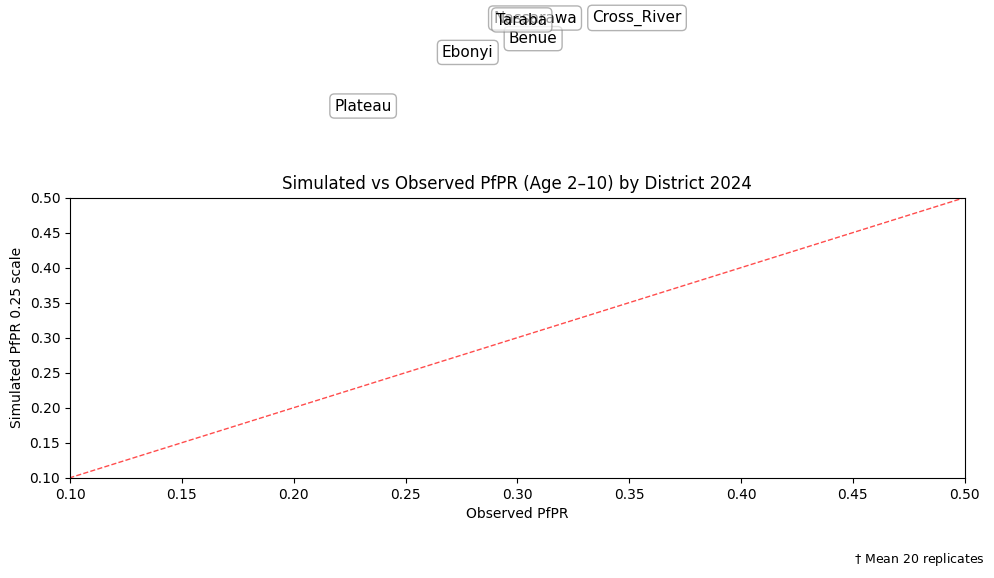

In [43]:
# ======================================================
# Figure 1: Simulated vs Observed PfPR by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d1 = compare_data[["mean_2_to_10_obs", "mean_2_to_10_sim", "State", "mean_population_sim"]].dropna(
    subset=["mean_2_to_10_obs", "mean_2_to_10_sim"]
)

sns.scatterplot(
    data=d1,
    x="mean_2_to_10_obs",
    y="mean_2_to_10_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

''' Use full range when trying to calibrate pipeline, narrow range yields better looking plots when finalized'''

# ax.set_xlim(0.0, 1.0)
# ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.1, 0.5)

span = min(ax.get_xlim()[1] - ax.get_xlim()[0], ax.get_ylim()[1] - ax.get_ylim()[0])

texts = d1["State"].astype(str).fillna("").tolist()
x = d1["mean_2_to_10_obs"].to_numpy(dtype=float)
y = d1["mean_2_to_10_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=11,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.02,
    min_distance=0.10 * span,
    max_distance=0.35 * span,
    nbr_candidates=3000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1, color="red", alpha=0.7)
ax.set_title(f"Simulated vs Observed PfPR (Age 2–10) by District {calibration_year}")
ax.set_xlabel("Observed PfPR")
ax.set_ylabel(f"Simulated PfPR {population_scale_from_input_yml} scale")

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='right', va='bottom', fontsize=9)
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

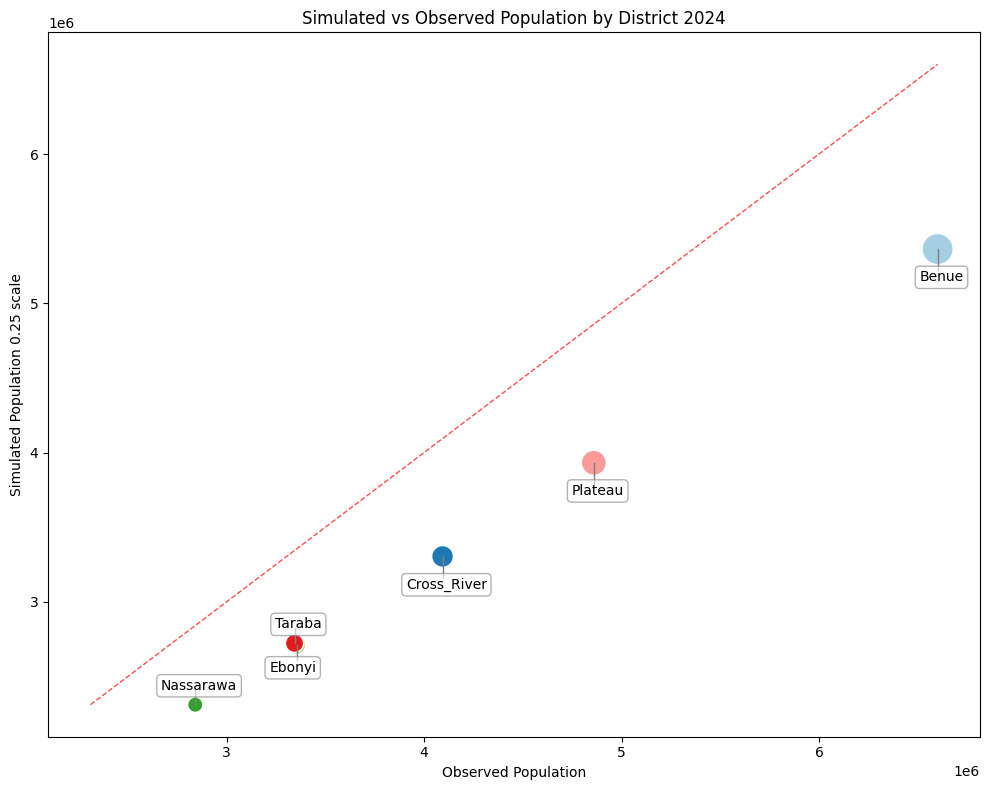

In [44]:
# ======================================================
# Figure 2: Simulated vs Observed Population by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d2 = compare_data[["population_obs", "mean_population_sim", "State"]].dropna(
    subset=["population_obs", "mean_population_sim"]
)

sns.scatterplot(
    data=d2,
    x="population_obs",
    y="mean_population_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

texts = d2["State"].astype(str).fillna("").tolist()
x = d2["population_obs"].to_numpy(dtype=float)
y = d2["mean_population_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=10,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.01,
    min_distance=0.01,
    max_distance=0.08,
    nbr_candidates=300,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

min_val = min(d2["population_obs"].min(), d2["mean_population_sim"].min())
max_val = max(d2["population_obs"].max(), d2["mean_population_sim"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="red", alpha=0.7)

ax.set_title(f"Simulated vs Observed Population by District {calibration_year}")
ax.set_xlabel("Observed Population")
ax.set_ylabel(f"Simulated Population {population_scale_from_input_yml} scale")

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Population_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

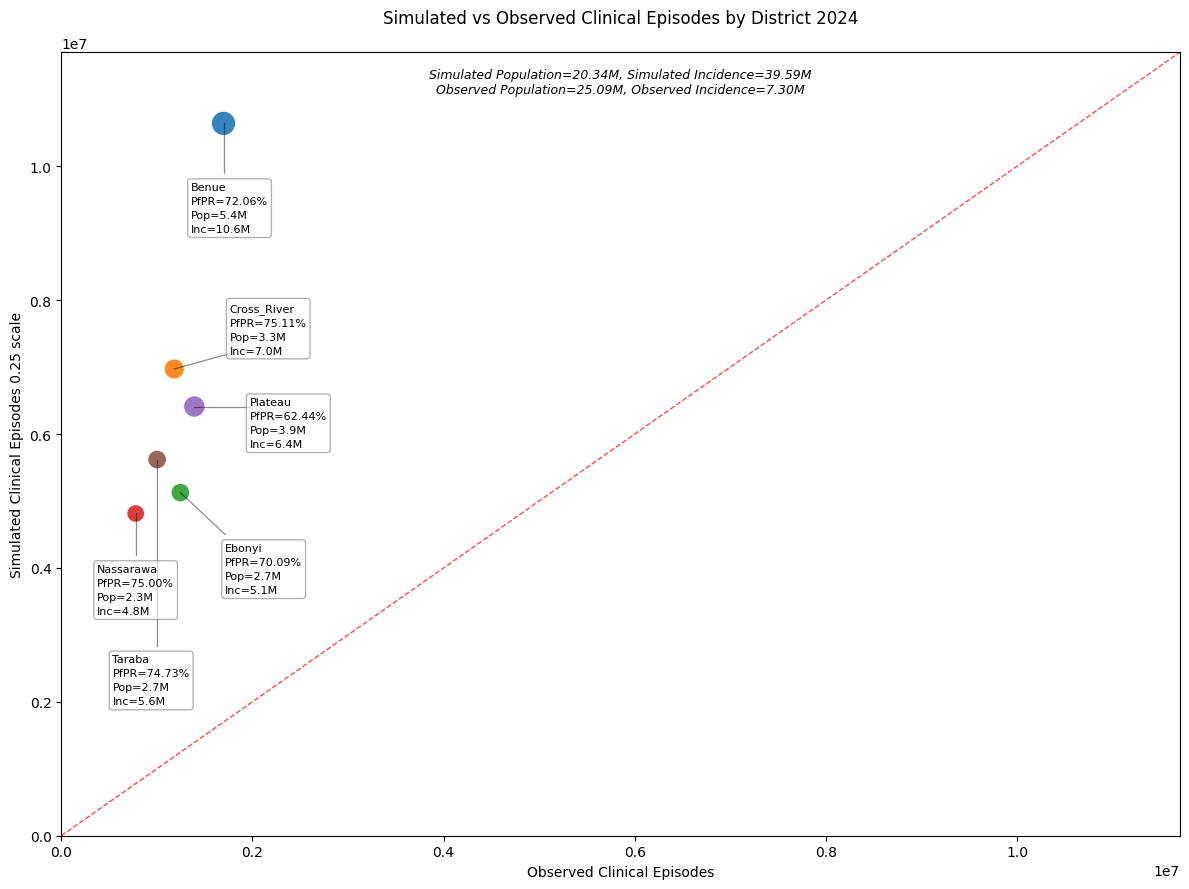

In [45]:
# ======================================================
# Figure 3: Simulated vs Observed Clinical Episodes by District
# ======================================================
fig, ax = plt.subplots(figsize=(12, 9))

d4 = compare_data[
    [
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "State",
        "mean_2_to_10_sim",
        "population_obs"
    ]
].dropna(
    subset=[
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "mean_2_to_10_sim",
        "population_obs"
    ]
).copy()

x = d4["annual_clinical_episodes_obs"].to_numpy(float)
# y = d4["mean_clinical_episodes_sim"].to_numpy(float)
y = d4["adjusted_mean_clinical_episodes_sim"].to_numpy(float)

pop = d4["mean_population_sim"].to_numpy(float)
sizes = (pop / pop.max()) * 250.0 + 50.0

total_pop_sim = d4["mean_population_sim"].sum()
# total_clinical_episodes_sim = d4["mean_clinical_episodes_sim"].sum()
total_clinical_episodes_sim = d4["adjusted_mean_clinical_episodes_sim"].sum()
total_pop_obs = d4["population_obs"].sum()
total_clinical_episodes_obs = d4["annual_clinical_episodes_obs"].sum()

texts = []
for _, row in d4.iterrows():
    name = str(row["State"])
    pfpr = row["mean_2_to_10_sim"]
    population = row["mean_population_sim"]
    # cases = row["mean_clinical_episodes_sim"]
    cases = row["adjusted_mean_clinical_episodes_sim"]
    label = f"{name}\nPfPR={pfpr*100:.2f}%\nPop={population/1e6:.1f}M\nInc={cases/1e6:.1f}M"
    texts.append(label)

districts = d4["State"].astype(str).tolist()
palette = sns.color_palette("tab10", n_colors=len(districts))
color_map = {name: palette[i] for i, name in enumerate(districts)}
colors = [color_map[name] for name in districts]

sc = ax.scatter(
    x, y,
    s=sizes,
    c=colors,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=2,
)

maxv = max(np.nanmax(x), np.nanmax(y)) * 1.10
ax.set_xlim(0, maxv)
ax.set_ylim(0, maxv)

linecolor = [(0, 0, 0, 0.45)] * len(x)

allocate(
    ax, x, y, texts,
    scatter_plot=sc,
    textsize=8,
    draw_lines=True,
    draw_all=True,
    linecolor=linecolor,
    linewidth=0.9,
    margin=0.03,
    min_distance=0.04,
    max_distance=0.38,
    nbr_candidates=5000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot(ax.get_xlim(), ax.get_ylim(), color="red", linestyle="--", linewidth=1, zorder=1, alpha=0.7)
ax.set_xlabel("Observed Clinical Episodes")
ax.set_ylabel(f"Simulated Clinical Episodes {population_scale_from_input_yml} scale")
ax.set_title(
    f"Simulated vs Observed Clinical Episodes by District {calibration_year}\n"
)

ax.text(
    0.5, 0.98,
    f"Simulated Population={total_pop_sim/1e6:.2f}M, Simulated Incidence={total_clinical_episodes_sim/1e6:.2f}M\n"
    f"Observed Population={total_pop_obs/1e6:.2f}M, Observed Incidence={total_clinical_episodes_obs/1e6:.2f}M",
    transform=ax.transAxes,
    fontsize=9, color="black", style="italic",
    ha="center", va="top"
)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Clinical_Episodes_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

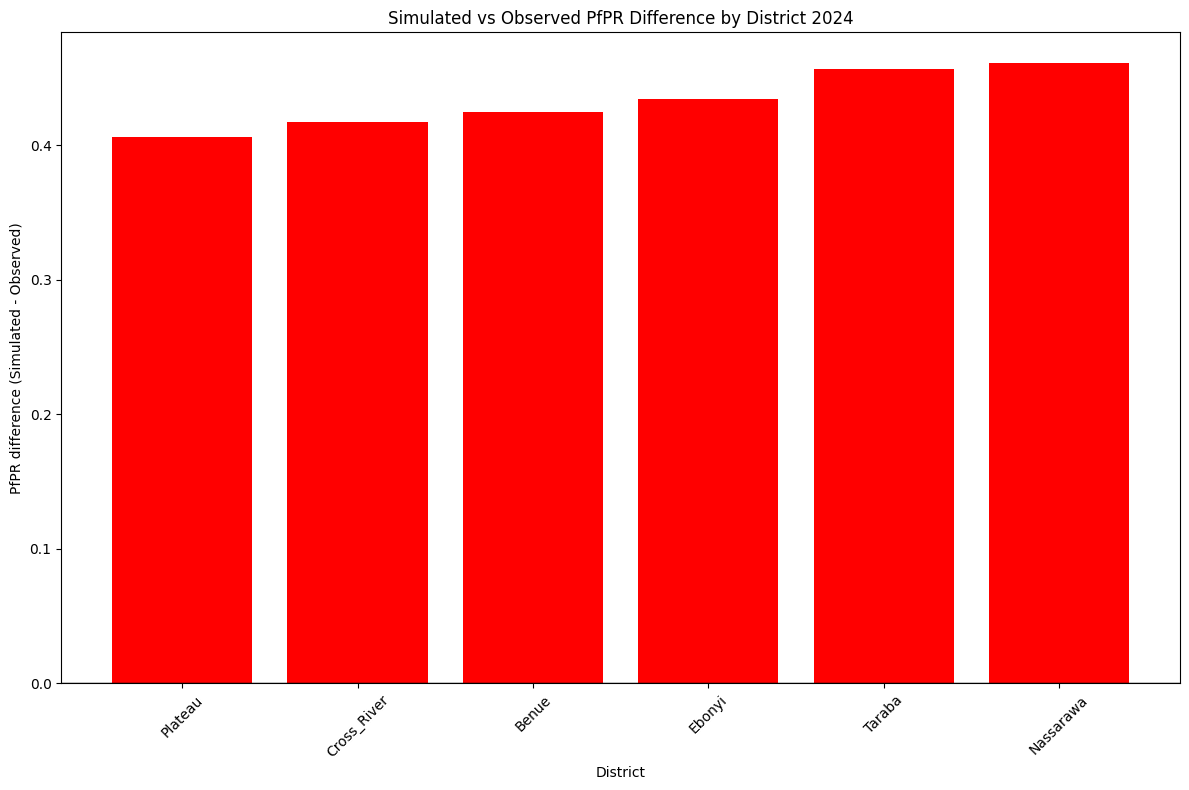

In [46]:
# ======================================================
# Figure 4: Simulated vs Observed PfPR difference by district
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8))

d3 = compare_data.copy()
d3["diff"] = d3["mean_2_to_10_sim"] - d3["mean_2_to_10_obs"]
d3 = d3.sort_values("diff")

colors = ["red" if d > 0 else "blue" for d in d3["diff"]]

ax.bar(d3["State"].astype(str), d3["diff"], color=colors)
ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("District")
ax.set_ylabel("PfPR difference (Simulated - Observed)")
ax.set_title(f"Simulated vs Observed PfPR Difference by District {calibration_year}")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_Difference_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()